In [128]:
from pathlib import Path
import sys
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import ast

In [129]:
PROJECT_DIR = Path.cwd().parent         
SCRIPTS_DIR = PROJECT_DIR / "scripts"
DATA_PROCESSED_DIR = PROJECT_DIR / "data_processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


from freq_analysis import word_frequencies, top_items
from entropy_utils import shannon_entropy
from ngrams import ngrams as word_ngrams
from pmi import pmi_df

In [130]:
clean_path = DATA_PROCESSED_DIR / "reddit_clean.csv"
df = pd.read_csv(clean_path)
print(df.head())
print(df.columns)
print(f"Número de comentarios: {len(df):,}")


                                                body          created_utc  \
0  Done - your wish is our command.  Graves shall...  2017-04-01 16:01:43   
1  I don't play league but goddam it if I'm not g...  2017-04-01 03:56:12   
2         http://imgur.com/a/8F7c6 WE DID IT REDDIT!  2017-04-01 04:01:06   
3                                        Seems legit  2017-04-01 00:55:50   
4  Graves no cigar, graves in peril, not to worry...  2017-04-01 01:19:17   

   score           created_dt        date  year  month year_month  \
0   2022  2017-04-01 16:01:43  2017-04-01  2017      4    2017-04   
1   4183  2017-04-01 03:56:12  2017-04-01  2017      4    2017-04   
2    267  2017-04-01 04:01:06  2017-04-01  2017      4    2017-04   
3    978  2017-04-01 00:55:50  2017-04-01  2017      4    2017-04   
4    670  2017-04-01 01:19:17  2017-04-01  2017      4    2017-04   

                                          text_clean  \
0  done your wish is our command graves shall onc...   
1  i don t

In [131]:
if isinstance(df["tokens_no_stop"].iloc[0], str):
    df["tokens_no_stop"] = df["tokens_no_stop"].apply(ast.literal_eval)

In [132]:
print(type(df["tokens_no_stop"].iloc[0]))
print(df["tokens_no_stop"].iloc[0][:10])


<class 'list'>
['wish', 'command', 'graves', 'shall', 'puffing', 'fat', 'stogie', 'like', 'true', 'badass']


In [133]:
# Flatten de todos los tokens_no_stop
all_tokens = [tok for toks in df["tokens_no_stop"] for tok in toks]
freq_counter = Counter(all_tokens) # o word_frequencies(all_tokens) si prefieres tu función

print(f"Número de tokens totales: {sum(freq_counter.values()):,}")
print(f"Tamaño del vocabulario: {len(freq_counter):,}")

# Top 50 palabras
top_50 = top_items(freq_counter, n=50)
top_50


Número de tokens totales: 271,816
Tamaño del vocabulario: 23,415


[('ok', 3503),
 ('just', 3288),
 ('like', 3061),
 ('yasuo', 3060),
 ('game', 2758),
 ('jesus', 2127),
 ('christ', 2089),
 ('play', 1711),
 ('team', 1456),
 ('people', 1446),
 ('good', 1411),
 ('time', 1279),
 ('really', 1266),
 ('riot', 1229),
 ('league', 1219),
 ('think', 1080),
 ('know', 971),
 ('lol', 900),
 ('got', 898),
 ('games', 883),
 ('make', 870),
 ('players', 845),
 ('did', 825),
 ('shit', 818),
 ('playing', 812),
 ('new', 753),
 ('actually', 727),
 ('way', 721),
 ('best', 707),
 ('better', 706),
 ('going', 701),
 ('fucking', 658),
 ('want', 647),
 ('t1', 643),
 ('love', 637),
 ('player', 617),
 ('year', 604),
 ('fuck', 594),
 ('years', 589),
 ('man', 585),
 ('fake', 574),
 ('moba', 554),
 ('right', 551),
 ('does', 550),
 ('support', 545),
 ('worlds', 543),
 ('need', 540),
 ('played', 538),
 ('thing', 526),
 ('bad', 515)]

In [134]:
top_words_df = pd.DataFrame(top_50, columns=["word", "freq"])

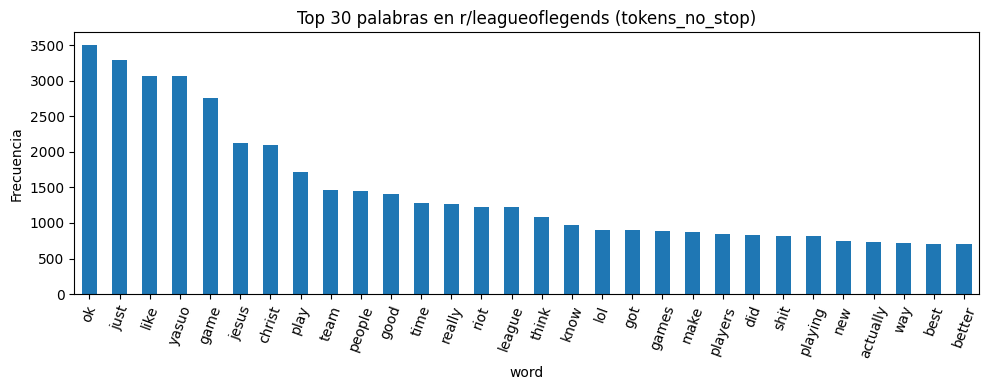

In [135]:
plt.figure(figsize=(10, 4))
top_words_df.head(30).set_index("word")["freq"].plot(kind="bar")
plt.title("Top 30 palabras en r/leagueoflegends (tokens_no_stop)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


In [136]:
def word_freq_by_year(df, col_tokens="tokens_no_stop"):
    results = []
    for year, sub in df.groupby("year"):
        tokens = [t for toks in sub[col_tokens] for t in toks]
        counter = Counter(tokens)
        for word, freq in counter.items():
            results.append({"year": year, "word": word, "freq": freq})
    return pd.DataFrame(results)

freq_year_df = word_freq_by_year(df)
freq_year_df.head()


,year,word,freq
0,2015,twitter,9
1,2015,dscarra,1
2,2015,status,7
3,2015,scarra,2
4,2015,###,1


In [137]:
for year in sorted(freq_year_df["year"].unique())[-5:]:
    print(f"\n===== {year} =====")
    sub = freq_year_df[freq_year_df["year"] == year].sort_values("freq", ascending=False).head(15)
    print(sub.to_string(index=False))



===== 2020 =====
 year   word  freq
 2020   just  1179
 2020   like  1148
 2020   game   927
 2020   play   587
 2020 people   467
 2020   riot   460
 2020   good   456
 2020 really   447
 2020   time   438
 2020 league   438
 2020   team   392
 2020    got   351
 2020   know   338
 2020  think   333
 2020    lol   320

===== 2021 =====
 year   word  freq
 2021   just   548
 2021   like   486
 2021   game   426
 2021   play   275
 2021   good   224
 2021 people   221
 2021   riot   220
 2021    new   201
 2021 league   196
 2021   time   189
 2021 really   189
 2021   team   186
 2021   know   176
 2021    lol   175
 2021  think   144

===== 2022 =====
 year    word  freq
 2022    just   156
 2022    like   136
 2022    game   131
 2022    riot   102
 2022    good    69
 2022  really    63
 2022  people    62
 2022    time    58
 2022  league    57
 2022  client    56
 2022     drx    55
 2022    play    54
 2022     got    54
 2022 fucking    49
 2022    shit    45

===== 2024 =====


In [138]:
freq_year_df.to_csv(OUTPUT_DIR / "word_freq_by_year.csv", index=False)


In [139]:
# Construir lista de bigramas a partir de tokens_no_stop
all_bigrams = []
for toks in df["tokens_no_stop"]:
    all_bigrams.extend(list(word_ngrams(toks, n=2)))  # asumiendo que tu ngrams recibe (tokens, n)

bigram_counts = Counter(all_bigrams)
len(bigram_counts), list(bigram_counts.items())[:5]


(185509,
 [('wish command', 2),
  ('command graves', 1),
  ('graves shall', 1),
  ('shall puffing', 1),
  ('puffing fat', 1)])

In [140]:
# Entropía por comentario
df["entropy_tokens"] = df["tokens_no_stop"].apply(shannon_entropy)

df[["body", "n_tokens", "entropy_tokens"]].head()


,body,n_tokens,entropy_tokens
0,Done - your wish is our command. Graves shall...,28,3.459432
1,I don't play league but goddam it if I'm not g...,25,3.121928
2,http://imgur.com/a/8F7c6 WE DID IT REDDIT!,9,2.000000
3,Seems legit,2,0.000000
4,"Graves no cigar, graves in peril, not to worry...",13,2.521641


In [141]:
df["entropy_tokens"].describe()


count    26259.000000
mean         2.504808
std          1.303727
min          0.000000
25%          1.584963
50%          2.500000
75%          3.321928
max          7.726643
Name: entropy_tokens, dtype: float64

In [142]:
entropy_by_year = (
    df.groupby("year")["entropy_tokens"]
      .mean()
      .reset_index()
      .sort_values("year")
)
entropy_by_year


,year,entropy_tokens
0,2015,2.300735
1,2016,2.507587
2,2017,2.305339
3,2018,2.249271
4,2019,2.386752
5,2020,2.395119
6,2021,2.412724
7,2022,2.523135
8,2024,2.763663
9,2025,3.042642


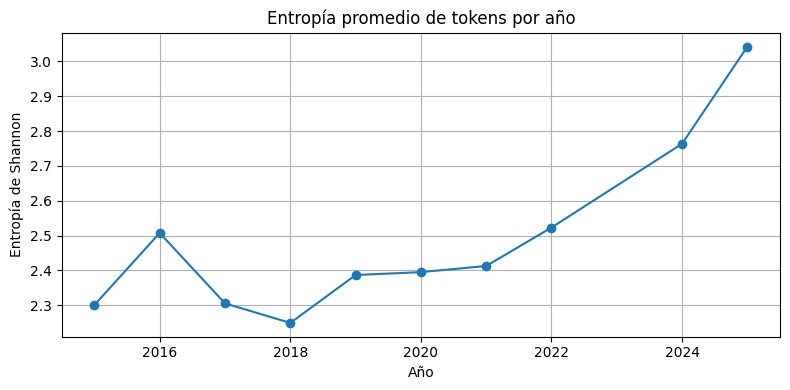

In [143]:
plt.figure(figsize=(8, 4))
plt.plot(entropy_by_year["year"], entropy_by_year["entropy_tokens"], marker="o")
plt.title("Entropía promedio de tokens por año")
plt.xlabel("Año")
plt.ylabel("Entropía de Shannon")
plt.grid(True)
plt.tight_layout()
plt.show()


In [144]:
# Ver top 200 palabras para cazar vocabulario de gameplay
top_200 = [w for w, f in top_items(freq_counter, n=200)]
print(top_200)


['ok', 'just', 'like', 'yasuo', 'game', 'jesus', 'christ', 'play', 'team', 'people', 'good', 'time', 'really', 'riot', 'league', 'think', 'know', 'lol', 'got', 'games', 'make', 'players', 'did', 'shit', 'playing', 'new', 'actually', 'way', 'best', 'better', 'going', 'fucking', 'want', 't1', 'love', 'player', 'year', 'fuck', 'years', 'man', 'fake', 'moba', 'right', 'does', 'support', 'worlds', 'need', 'played', 'thing', 'bad', 'champion', 'getting', 'feel', 'll', 'skin', 'didn', 'doesn', 'lane', 'great', 'say', 'win', 'faker', 'fun', 'looks', 'lot', 'look', 'pretty', 'video', 'enemy', 'champ', 'sure', 'hope', 'adc', 'jungle', 'probably', 'day', 'work', 'mid', 'thought', 'gonna', 'champions', 'hard', 'makes', 'watch', 'post', 'holy', 'level', 'guy', 'end', 'maybe', 'nice', 'seen', 'champs', 'long', 'old', 'let', 'literally', 'ult', 'try', 'lmao', 'isn', 'use', 'god', 'season', 'real', 'won', 'said', 'guma', 'damage', 'big', 'wait', 'world', 'cool', 'things', 'doing', 'damn', 'point', 'oh

In [145]:
GAME_MECHANICS_WORDS = {
    "kill", "killed", "killing",
    "dead", "die", "dying",
    "damage", "execute", "executed",
    'fight', 

    "tower", "turret", "nexus", "inhib", "inhibitor",
    "minion", "wave", "cs", "farm", "farming",

    "dragon", "drake", "baron", "herald",
    "rift", "elder", "nashor",

    "jungle", "lane", "top", "mid", "bot", "support", "adc", "jgl", "jg",
    # campeones y abreviaciones típicas: "yasuo", "zed", etc. si quieres

    "gg", "ff", "surrender", "inting", "gank", "roam", "reset",
}


In [146]:
import json

with open(OUTPUT_DIR / "game_mechanics_words.json", "w", encoding="utf-8") as f:
    json.dump(sorted(GAME_MECHANICS_WORDS), f, ensure_ascii=False, indent=2)

print("✅ Guardado game_mechanics_words.json")


✅ Guardado game_mechanics_words.json
